## **Data Loading and Initial Look**:


In [1]:
# Importing Necessary Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/content/sample_data/pcos_dataset.csv')
print(df.head())

   Age   BMI  Menstrual_Irregularity  Testosterone_Level(ng/dL)  \
0   24  34.7                       1                       25.2   
1   37  26.4                       0                       57.1   
2   32  23.6                       0                       92.7   
3   28  28.8                       0                       63.1   
4   25  22.1                       1                       59.8   

   Antral_Follicle_Count  PCOS_Diagnosis  
0                     20               0  
1                     25               0  
2                     28               0  
3                     26               0  
4                      8               0  


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Age                        1000 non-null   int64  
 1   BMI                        1000 non-null   float64
 2   Menstrual_Irregularity     1000 non-null   int64  
 3   Testosterone_Level(ng/dL)  1000 non-null   float64
 4   Antral_Follicle_Count      1000 non-null   int64  
 5   PCOS_Diagnosis             1000 non-null   int64  
dtypes: float64(2), int64(4)
memory usage: 47.0 KB


In [4]:
df.describe()

,Age,BMI,Menstrual_Irregularity,Testosterone_Level(ng/dL),Antral_Follicle_Count,PCOS_Diagnosis
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000
mean,31.771000,26.38700,0.530000,60.159500,17.469000,0.199000
std,8.463462,4.93554,0.499349,23.160204,7.069301,0.399448
min,18.000000,18.10000,0.000000,20.000000,5.000000,0.000000
25%,24.000000,21.90000,0.000000,41.700000,12.000000,0.000000
50%,32.000000,26.40000,1.000000,60.000000,18.000000,0.000000
75%,39.000000,30.50000,1.000000,80.300000,23.250000,0.000000
max,45.000000,35.00000,1.000000,99.800000,29.000000,1.000000


In [5]:
df.shape

(1000, 6)

In [6]:
# Menstrual Irregularity Distribution
# No = 0 and Yes = 1

print(df['Menstrual_Irregularity'].value_counts())

Menstrual_Irregularity
1    530
0    470
Name: count, dtype: int64


In [7]:
# Diagnosis Distribution
# No = 0 and Yes = 1

print(df['PCOS_Diagnosis'].value_counts())

PCOS_Diagnosis
0    801
1    199
Name: count, dtype: int64


In [8]:
# Find Missing Values
print("Number of missing values in each column:")
print(df.isnull().sum())


# Find Duplicated Values
print("\nNumber of duplicated rows:", df.duplicated().sum())

Number of missing values in each column:
Age                          0
BMI                          0
Menstrual_Irregularity       0
Testosterone_Level(ng/dL)    0
Antral_Follicle_Count        0
PCOS_Diagnosis               0
dtype: int64

Number of duplicated rows: 0


## **Data Visualization**:

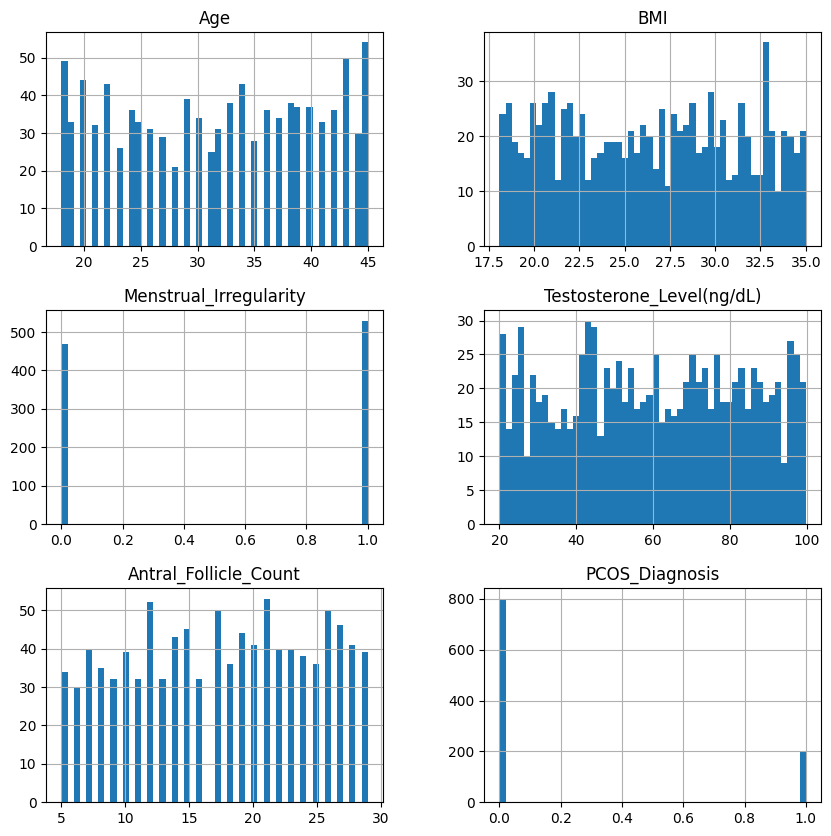

In [9]:
# Visualizing the distribution of each feature

df.hist(figsize=(10, 10), bins=50)
plt.show()

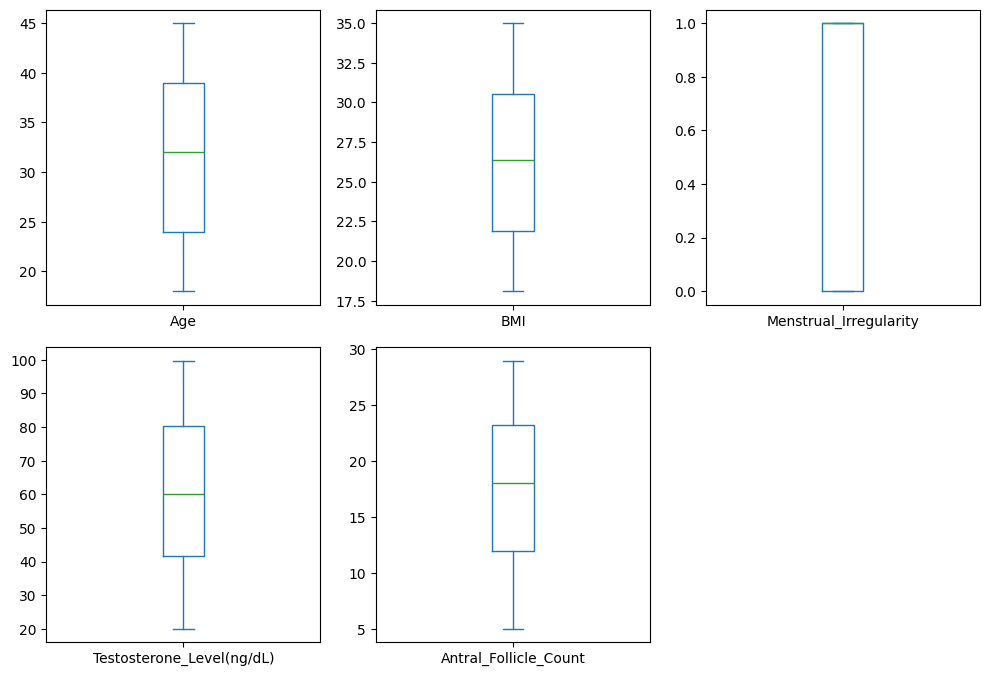

In [10]:
# Detecting Outliers with a Box Plot

columns = ['Age', 'BMI', 'Menstrual_Irregularity', 'Testosterone_Level(ng/dL)', 'Antral_Follicle_Count']

df[columns].plot(kind='box', subplots=True, layout=(3, 3), figsize=(10, 10))
plt.tight_layout()
plt.show()

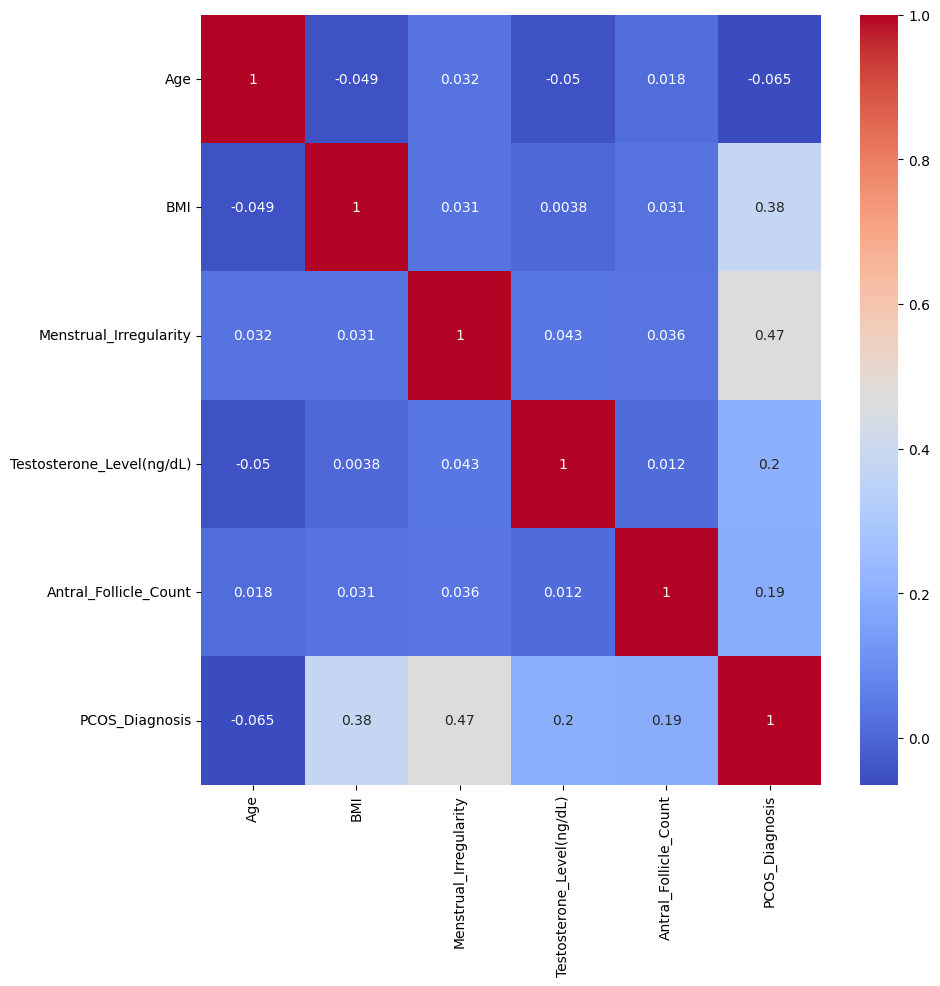

In [11]:
# Checking for Multicollinearity

correlation_matrix = df.corr()
plt.figure(figsize=(10, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.show()

## **Data Cleaning and Preparation for Machine Learning**:

In [12]:
# Scaling Features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = df.drop(['PCOS_Diagnosis'], axis=1)  # Exclude target variable
X_scaled = scaler.fit_transform(X)  # Scale only the features

df_scaled = pd.DataFrame(X_scaled, columns=X.columns)
df_scaled['PCOS_Diagnosis'] = df['PCOS_Diagnosis']  # Add target variable back

df = df_scaled  # Update the dataframe
print(df.head())

        Age       BMI  Menstrual_Irregularity  Testosterone_Level(ng/dL)  \
0 -0.918642  1.685157                0.941697                  -1.510220   
1  0.618141  0.002635               -1.061913                  -0.132168   
2  0.027071 -0.564962               -1.061913                   1.405721   
3 -0.445785  0.489148               -1.061913                   0.127027   
4 -0.800428 -0.869033                0.941697                  -0.015530   

   Antral_Follicle_Count  PCOS_Diagnosis  
0               0.358206               0  
1               1.065844               0  
2               1.490426               0  
3               1.207371               0  
4              -1.340124               0  


## **Machine Learning**:

In [13]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [14]:
# Define features and target variables
X = df.drop(['PCOS_Diagnosis'], axis=1)
y = df['PCOS_Diagnosis']

# Splitting into training and test sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Create KNN Model
knn_classifier = KNeighborsClassifier(n_neighbors=5)
knn_classifier.fit(X_train, y_train)

# Make predictions using KNN Model
knn_predictions = knn_classifier.predict(X_val)

# Evaluate and Compare the Metric
accuracy = accuracy_score(y_val, knn_predictions)

print(f"Validation Accuracy: {accuracy:.2f}")

Validation Accuracy: 0.97


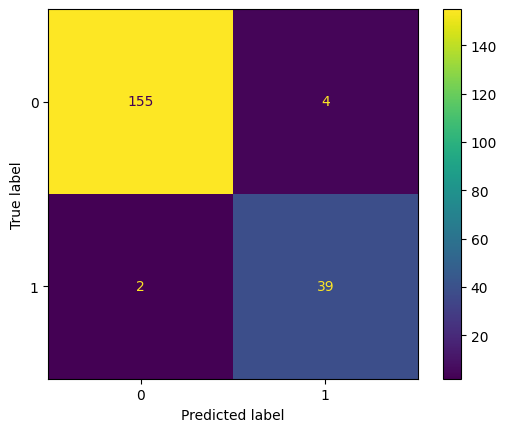

In [15]:
# Create Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_val, knn_predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

#### Based on the above confusion matrix, here are the statistics:
##### Number of True Negatives: 155
##### Number of False Negatives: 2
##### Number of True Positives: 39
##### Number of False Positives: 4